In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
BRANCH_A = "cuda-branchless-dequantization-float32-lut"
BRANCH_B = "cuda-branchless-dequantization-shfl-sync"
data_csv = "plot_diff.csv"

dfs = []
for branch in [BRANCH_A, BRANCH_B]:
    df = pd.read_csv(os.path.join(branch, data_csv))
    df["branch"] = branch
    dfs.append(df)

df = pd.concat(dfs)

for i in range(2):
    columns = dfs[i].columns
    index = columns[:6].tolist()
    values = columns[6:]
    dfs[i] = dfs[i].groupby(index)[values].first().drop(columns="branch")

diff_df = dfs[0] - dfs[1]

diff_df

latency_total_diff_%  \
model         input_size output_size config index   batch_size                         
Llama-3.1-70B 2048       128         nf4    decode  1                       2.021639   
                                                    4                       3.485010   
                                                    8                       2.272357   
                                                    16                      2.292139   
                                            prefill 1                       1.679409   
                                                    4                       0.584490   
                                                    8                       0.156441   
                                                    16                      0.141826   

                                                                latency_mean_diff_%  \
model         input_size output_size config index   batch_size                        
Llama-3.1-70B 2048       128         nf4    decode  1                      2.021639   
                                                    4                      3.485010   
                                                    8                      2.272357   
                                                    16                     2.292139   
                                            prefill 1                      1.679409   
                                                    4                      0.584490   
                                                    8                      0.156441   
                                                    16                     0.141826   

                                                                latency_p50_diff_%  \
model         input_size output_size config index   batch_size                       
Llama-3.1-70B 2048       128         nf4    decode  1                     2.015621   
                                                    4                     3.450948   
                                                    8                     2.289270   
                                                    16                    2.263115   
                                            prefill 1                     1.641213   
                                                    4                     0.559915   
                                                    8                     0.140781   
                                                    16                    0.153126   

                                                                throughput_value_diff_%  
model         input_size output_size config index   batch_size                           
Llama-3.1-70B 2048       128         nf4    decode  1                          1.981996  
                                                    4                          6.091749  
                                                    8                          3.914805  
                                                    16                         3.835137  
                                            prefill 1                          2.071096  
                                                    4                          0.626949  
                                                    8                          0.161381  
                                                    16                         0.143483

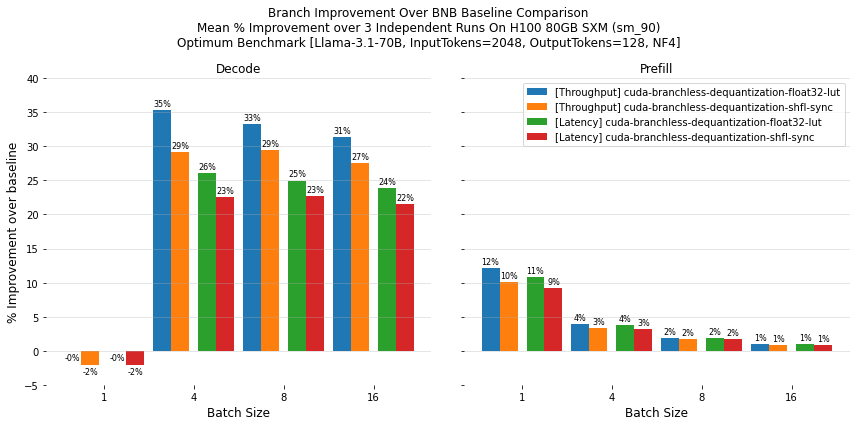

In [3]:
# plot everything in one plot
# assumes all experiments have the exact same data (model name, input tokens, output tokens)
n_runs = 3
model_name, input_size, output_size = df.iloc[0][:3].tolist()
fig, axes = plt.subplots(ncols=2, figsize=(12,6), sharey=True)

x_axis = df["batch_size"].unique()
xticks = np.array(list(range(len(x_axis))))

columns = ["throughput_value_diff_%", "latency_mean_diff_%"]
labels = ["Throughput", "Latency"]
lines = []
width = 0.2
gap = 0.1
for i, (axis, (inference_type, sub_df)) in enumerate(zip(axes.flat, df.groupby("index"))):
    axis.set_xticks(xticks)
    axis.set_xticklabels(x_axis)
    offsets = [-1.5*width - gap/2,
               -0.5*width - gap/2,
                0.5*width + gap/2,
                1.5*width + gap/2]

    for col, col_name in zip(columns, labels):
        for branch_name, sub_df2 in sub_df.groupby("branch"):
            assert sub_df2.shape[0] == x_axis.shape[0]
            offset = offsets.pop(0)
            bars = axis.bar(xticks + offset, sub_df2[col], width=width, label=f"[{col_name}] {branch_name}")
            axis.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=8)

    axis.set_title(inference_type.capitalize())
    axis.set_xlabel('Batch Size', fontsize=12)
    if i == 0:
        axis.set_ylabel('% Improvement over baseline', fontsize=12)
    if i == 1:
        axis.legend(loc='upper right')
    axis.set_facecolor("white")
    fig.patch.set_facecolor("white")

    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.set_ylim(-5, 40)
    axis.grid(True, axis='y', alpha=0.4)

plt.suptitle(
    "Branch Improvement Over BNB Baseline Comparison"
    f"\nMean % Improvement over 3 Independent Runs On H100 80GB SXM (sm_90)"
    f"\nOptimum Benchmark [{model_name}, InputTokens={input_size}, OutputTokens={output_size}, NF4]"
    # f"\n{BRANCH_A} vs {BRANCH_B}"
)
plt.tight_layout()
plt.show()
fig.savefig("side_by_side_comparison.png", dpi=300, bbox_inches='tight', facecolor='white')